# Autocovariance and Autocorrelation in Time Series Analysis

## 1. Introduction

In time series analysis, understanding the **dependence structure** between observations at different time points is crucial. Two fundamental tools for this are:

- **Autocovariance**: Measures the covariance between a time series and a lagged version of itself.
- **Autocorrelation**: Measures the *normalized* correlation between a time series and a lagged version of itself.

These concepts help us identify:
- Trends and seasonality
- Suitable model orders (e.g., ARIMA)
- Whether a series is stationary or not
- 

## 2. Mathematical Definitions

### Autocovariance Function (ACVF)

For a time series $x_t$ with mean $\mu$, the **autocovariance at lag $k$** is:

$$\gamma(k) = \text{Cov}(x_t, x_{t-k}) = E\left[(x_t - \mu)(x_{t-k} - \mu)\right]$$

For a sample of $N$ observations, the **sample autocovariance** is estimated as:

$$\hat{\gamma}(k) = \frac{1}{N} \sum_{t=k+1}^{N} (x_t - \bar{x})(x_{t-k} - \bar{x})$$

> Note: Some implementations use $N-k$ in the denominator (unbiased estimator). We use $N$ here for consistency with `statsmodels`.

### Autocorrelation Function (ACF)

The **autocorrelation at lag $k$** normalizes autocovariance by the variance:

$$\rho(k) = \frac{\gamma(k)}{\gamma(0)} = \frac{\text{Cov}(x_t, x_{t-k})}{\text{Var}(x_t)}$$

where $\gamma(0)$ is the variance of the series. By definition, $\rho(0) = 1$.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic time series
N = 200
t = np.arange(N)

# 1. White Noise: no autocorrelation
white_noise = np.random.normal(0, 1, N)

# 2. Trend series: strong autocorrelation at all lags
trend = 0.05 * t + np.random.normal(0, 0.5, N)

# 3. Seasonal series: periodic autocorrelation
seasonal = 2 * np.sin(2 * np.pi * t / 12) + np.random.normal(0, 0.3, N)

# 4. AR(1) process: x_t = 0.7*x_{t-1} + epsilon_t
ar1 = np.zeros(N)
for i in range(1, N):
    ar1[i] = 0.7 * ar1[i-1] + np.random.normal(0, 0.5)

print("Synthetic time series generated successfully!")
print(f"White noise mean: {white_noise.mean():.3f}, std: {white_noise.std():.3f}")
print(f"AR(1) mean: {ar1.mean():.3f}, std: {ar1.std():.3f}")


Synthetic time series generated successfully!
White noise mean: -0.041, std: 0.929
AR(1) mean: 0.012, std: 0.677


## 3. Manual Implementation of Autocovariance and Autocorrelation

Let's implement these functions from scratch to understand the mechanics, then compare with `statsmodels`.


In [22]:
def manual_autocovariance(x, max_lags=40):
    """
    Compute sample autocovariance for lags 0 to max_lags.
    Uses denominator N (not N-k) for consistency with statsmodels.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)
    max_lags = min(max_lags, N - 1)
    
    x_centered = x - x.mean()
    autocov = np.zeros(max_lags + 1)
    
    for k in range(max_lags + 1):
        # Sum of x_t * x_{t-k} for t = k to N-1
        autocov[k] = np.sum(x_centered[k:] * x_centered[:N-k]) / N
    
    return autocov


def manual_autocorrelation(x, max_lags=40):
    """
    Compute sample autocorrelation by normalizing autocovariance.
    """
    autocov = manual_autocovariance(x, max_lags)
    # Normalize by variance (autocovariance at lag 0)
    autocorr = autocov / autocov[0]
    return autocorr


# Test on white noise
lags = 40
manual_acf_wn = manual_autocorrelation(white_noise, lags)
sm_acf_wn = acf(white_noise, nlags=lags, fft=True)

print("Comparison: Manual vs Statsmodels ACF (White Noise)")
print(f"Lag 0: Manual={manual_acf_wn[0]:.6f}, SM={sm_acf_wn[0]:.6f}")
print(f"Lag 1: Manual={manual_acf_wn[1]:.6f}, SM={sm_acf_wn[1]:.6f}")
print(f"Lag 5: Manual={manual_acf_wn[5]:.6f}, SM={sm_acf_wn[5]:.6f}")
print(f"Max diff: {np.max(np.abs(manual_acf_wn - sm_acf_wn)):.2e}")


Comparison: Manual vs Statsmodels ACF (White Noise)
Lag 0: Manual=1.000000, SM=1.000000
Lag 1: Manual=-0.051568, SM=-0.051568
Lag 5: Manual=0.108843, SM=0.108843
Max diff: 6.94e-17


## 4. Visualizing the Time Series


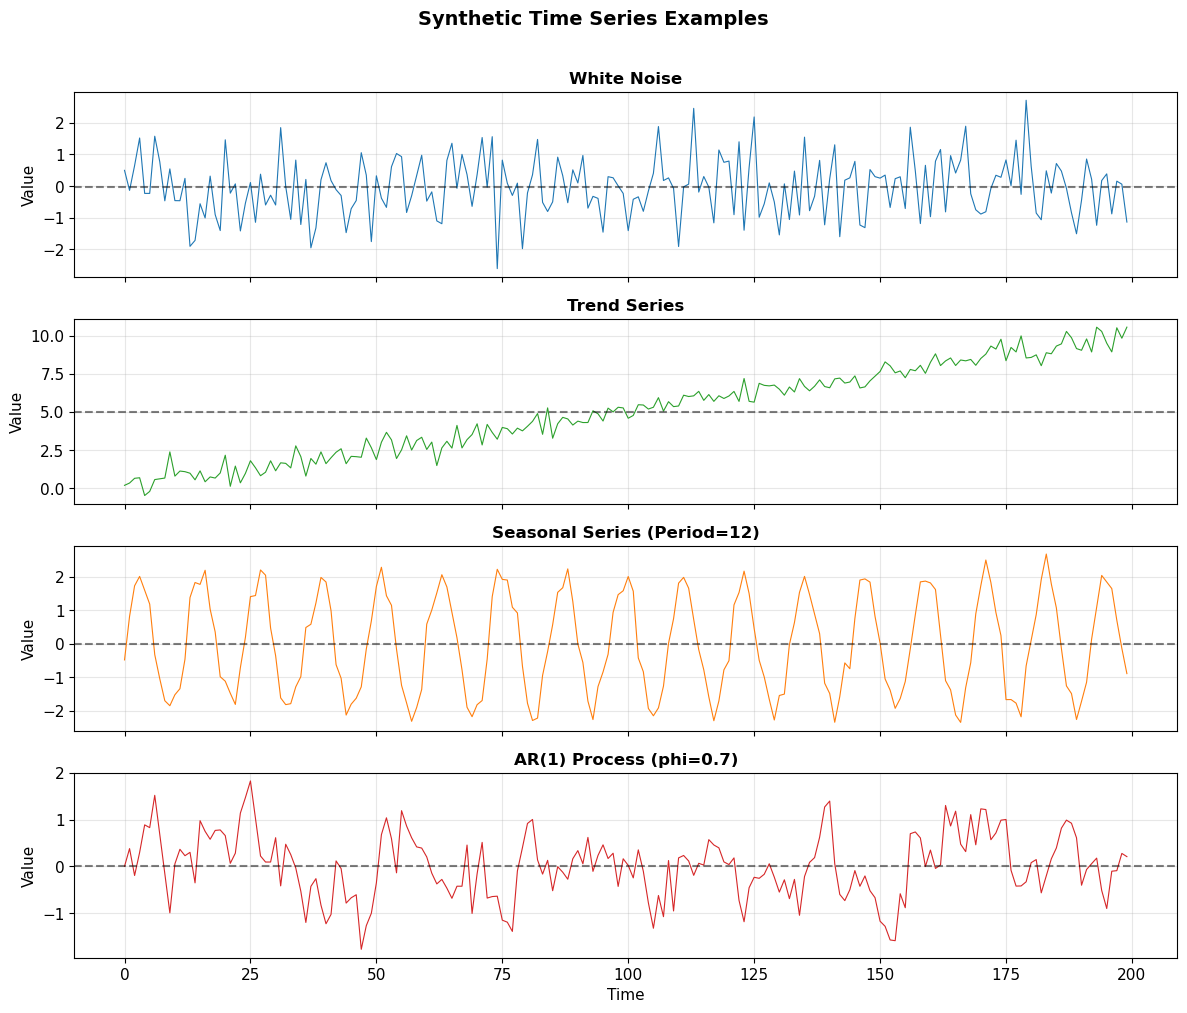

In [23]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

series_list = [
    (white_noise, "White Noise", "tab:blue"),
    (trend, "Trend Series", "tab:green"),
    (seasonal, "Seasonal Series (Period=12)", "tab:orange"),
    (ar1, "AR(1) Process (phi=0.7)", "tab:red")
]

for ax, (data, title, color) in zip(axes, series_list):
    ax.plot(t, data, color=color, linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.axhline(y=data.mean(), color='black', linestyle='--', alpha=0.5, label='Mean')

axes[-1].set_xlabel("Time")
plt.suptitle("Synthetic Time Series Examples", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Autocorrelation Function (ACF) Visualization

The ACF plot (also called a **correlogram**) shows autocorrelation values at different lags. The blue shaded region represents the 95% confidence interval for white noise.

**Interpretation guidelines:**
- **White noise**: ACF near zero for all lags > 0
- **Trend**: ACF decays very slowly
- **Seasonal**: ACF shows peaks at the seasonal period
- **AR(1)**: ACF decays exponentially
- 

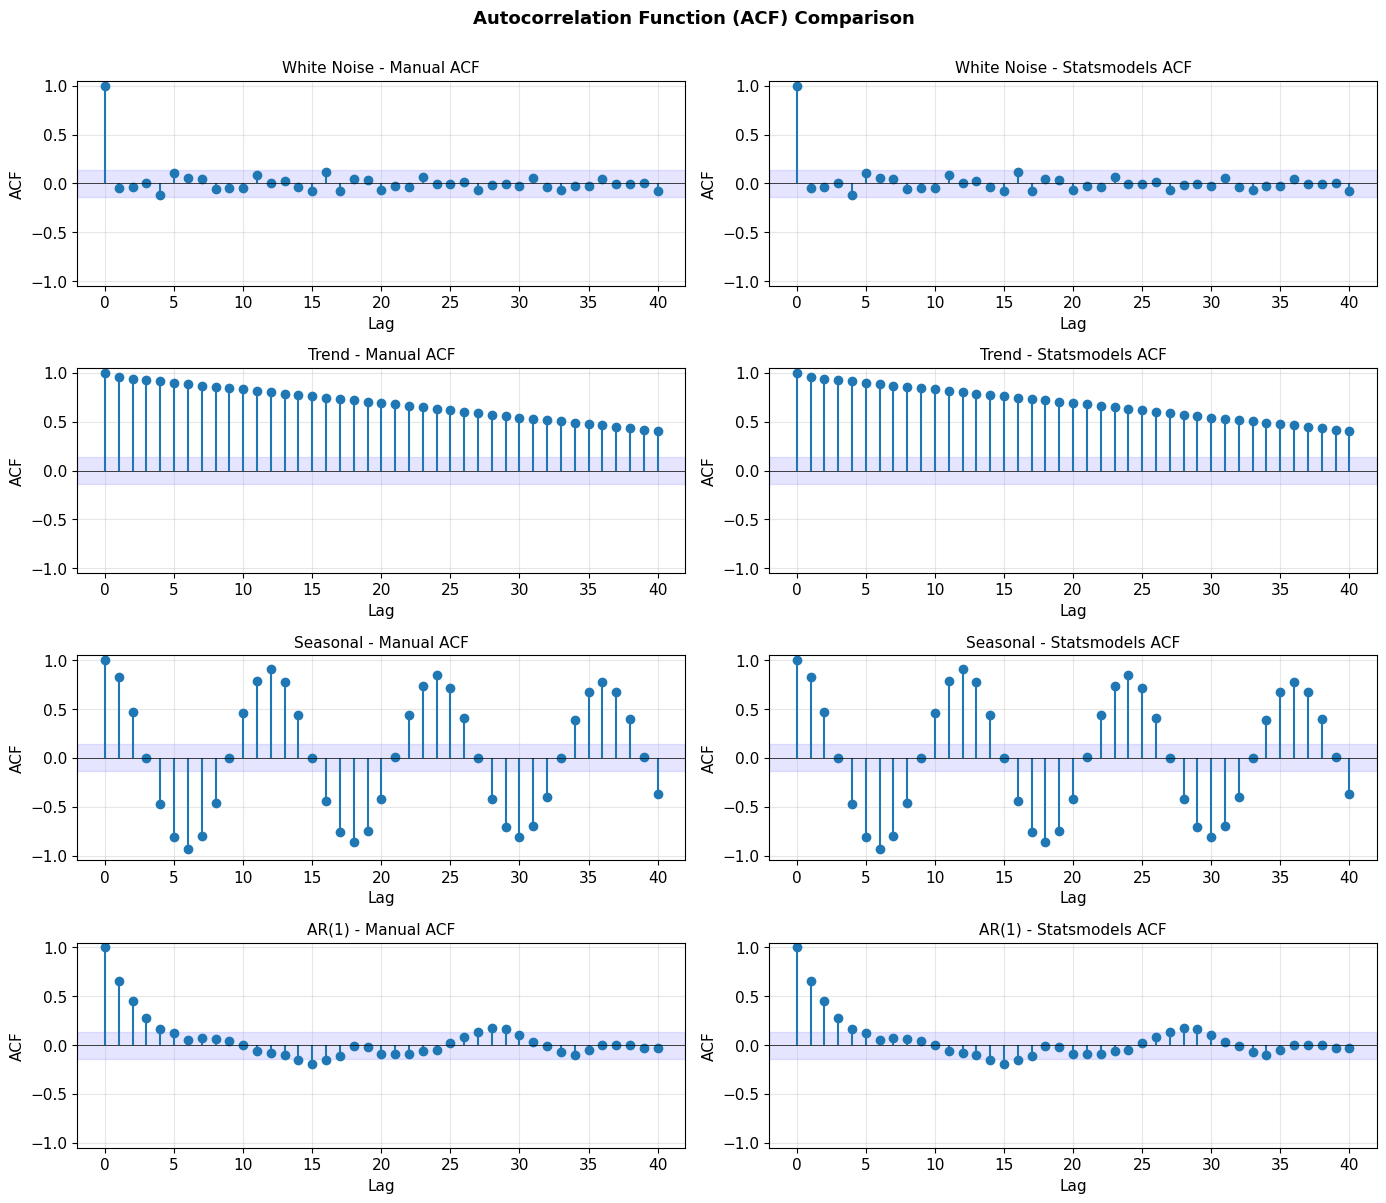

In [24]:
def plot_acf_comparison(series_dict, max_lags=40):
    """
    Plot ACF for multiple series using manual calculation and statsmodels.
    """
    n_series = len(series_dict)
    fig, axes = plt.subplots(n_series, 2, figsize=(14, 3 * n_series))
    
    if n_series == 1:
        axes = axes.reshape(1, -1)
    
    lags_arr = np.arange(max_lags + 1)
    
    # Confidence interval for white noise: approx +/- 1.96/sqrt(N)
    # This is a rough approximation for visualization
    conf_bound = 1.96 / np.sqrt(N)
    
    for idx, (name, data) in enumerate(series_dict.items()):
        # Left: Manual ACF
        manual_vals = manual_autocorrelation(data, max_lags)
        axes[idx, 0].stem(lags_arr, manual_vals, basefmt=" ")
        axes[idx, 0].axhline(y=0, color='black', linewidth=0.5)
        axes[idx, 0].axhspan(-conf_bound, conf_bound, color='blue', alpha=0.1)
        axes[idx, 0].set_title(f"{name} - Manual ACF", fontsize=11)
        axes[idx, 0].set_xlabel("Lag")
        axes[idx, 0].set_ylabel("ACF")
        axes[idx, 0].set_ylim(-1.05, 1.05)
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Right: Statsmodels ACF
        sm_vals = acf(data, nlags=max_lags, fft=True)
        axes[idx, 1].stem(lags_arr, sm_vals, basefmt=" ")
        axes[idx, 1].axhline(y=0, color='black', linewidth=0.5)
        axes[idx, 1].axhspan(-conf_bound, conf_bound, color='blue', alpha=0.1)
        axes[idx, 1].set_title(f"{name} - Statsmodels ACF", fontsize=11)
        axes[idx, 1].set_xlabel("Lag")
        axes[idx, 1].set_ylabel("ACF")
        axes[idx, 1].set_ylim(-1.05, 1.05)
        axes[idx, 1].grid(True, alpha=0.3)
    
    plt.suptitle("Autocorrelation Function (ACF) Comparison", fontsize=13, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.show()


series_dict = {
    "White Noise": white_noise,
    "Trend": trend,
    "Seasonal": seasonal,
    "AR(1)": ar1
}

plot_acf_comparison(series_dict, max_lags=40)


## 6. Autocovariance Function (ACVF) Visualization

Unlike ACF, autocovariance is **not normalized**. It preserves the scale of the original series. The value at lag 0 equals the variance of the series.


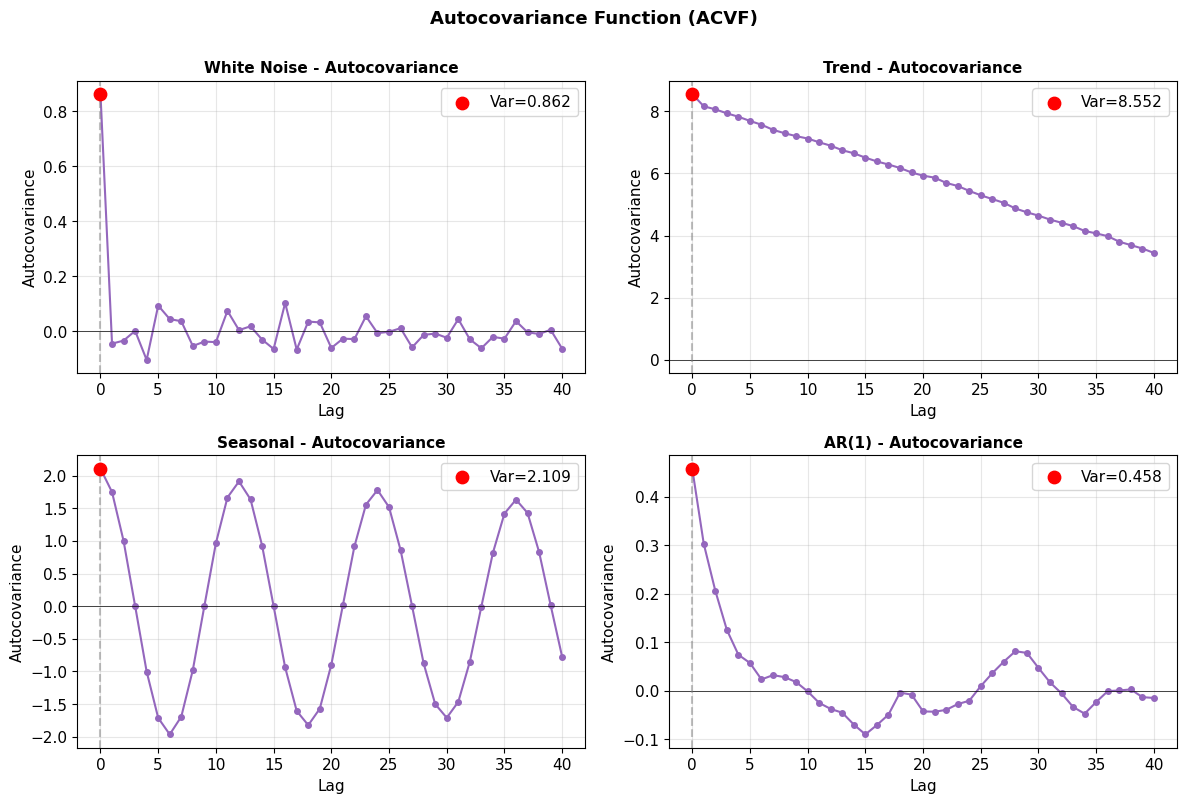

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

series_items = [
    ("White Noise", white_noise),
    ("Trend", trend),
    ("Seasonal", seasonal),
    ("AR(1)", ar1)
]

lags_arr = np.arange(41)

for ax, (name, data) in zip(axes, series_items):
    autocov = manual_autocovariance(data, 40)
    
    ax.plot(lags_arr, autocov, marker='o', markersize=4, linewidth=1.5, color='tab:purple')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Highlight lag 0 (variance)
    ax.scatter([0], [autocov[0]], color='red', s=80, zorder=5, label=f"Var={autocov[0]:.3f}")
    
    ax.set_title(f"{name} - Autocovariance", fontsize=11, fontweight='bold')
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocovariance")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

plt.suptitle("Autocovariance Function (ACVF)", fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


## 7. Partial Autocorrelation Function (PACF)

While ACF measures direct and indirect correlations, **PACF** measures the correlation at lag $k$ *after removing* the effect of intermediate lags (1, 2, ..., k-1).

PACF is especially useful for identifying the order of AR processes:
- **AR(p)**: PACF cuts off after lag p
- **MA(q)**: ACF cuts off after lag q
- 

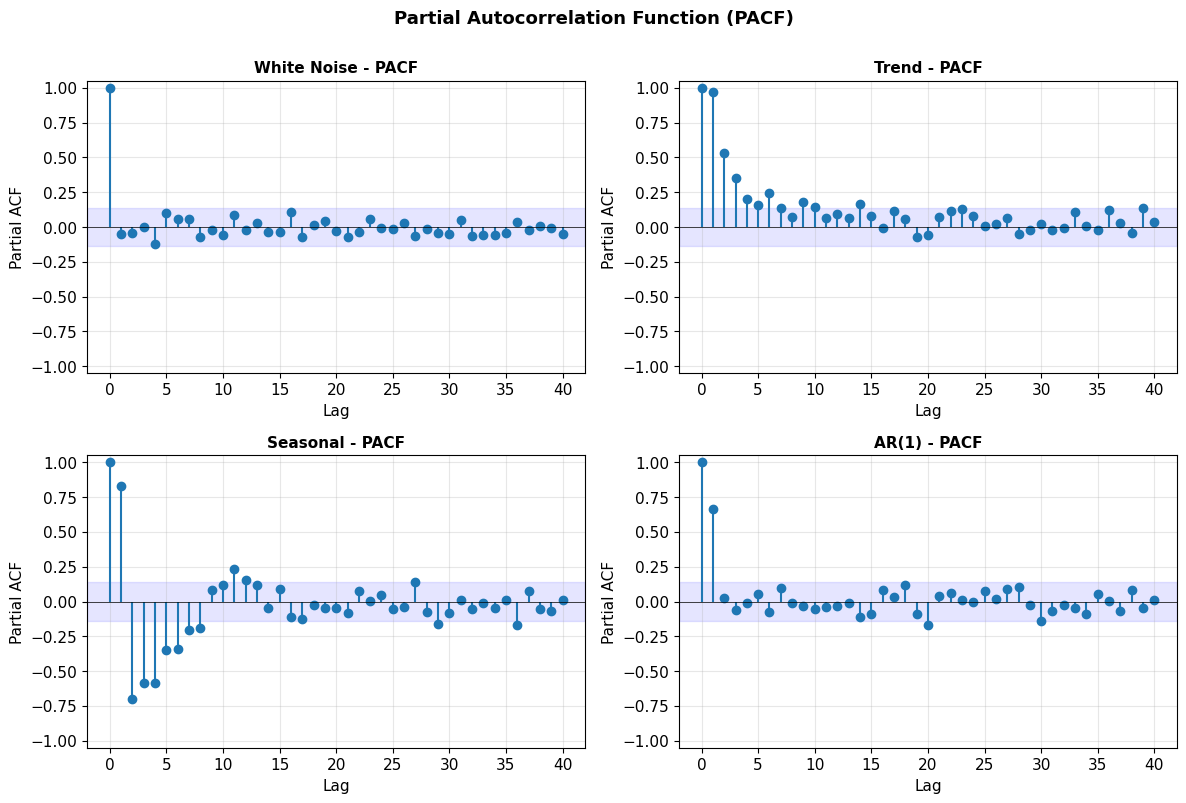

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

conf_bound = 1.96 / np.sqrt(N)

for ax, (name, data) in zip(axes, series_items):
    # Compute PACF using statsmodels
    pacf_vals = pacf(data, nlags=40, method='ols')
    lags_arr = np.arange(len(pacf_vals))
    
    ax.stem(lags_arr, pacf_vals, basefmt=" ")
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhspan(-conf_bound, conf_bound, color='blue', alpha=0.1)
    
    ax.set_title(f"{name} - PACF", fontsize=11, fontweight='bold')
    ax.set_xlabel("Lag")
    ax.set_ylabel("Partial ACF")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle("Partial Autocorrelation Function (PACF)", fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


## 8. Lag Scatter Plots (Visualizing Dependence)

Another intuitive way to understand autocorrelation is to plot $x_t$ vs $x_{t-k}$ for various lags $k$. A strong linear pattern indicates high autocorrelation.


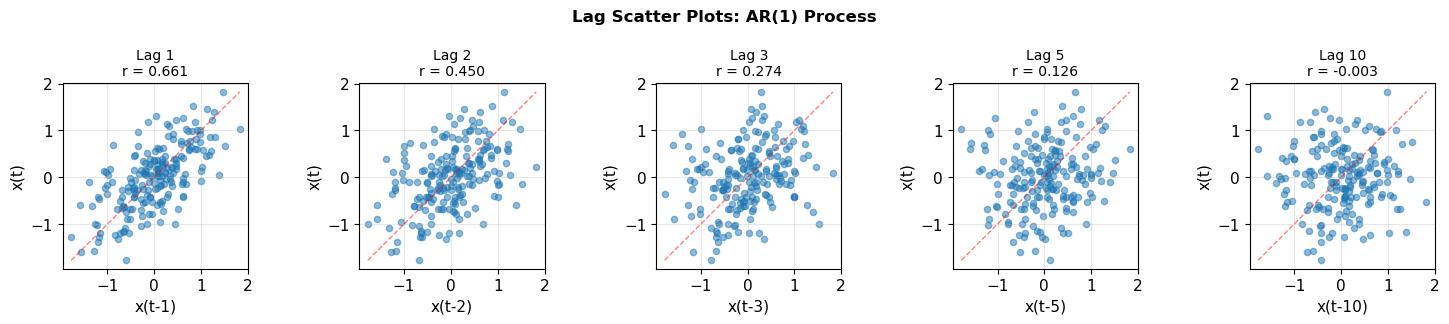

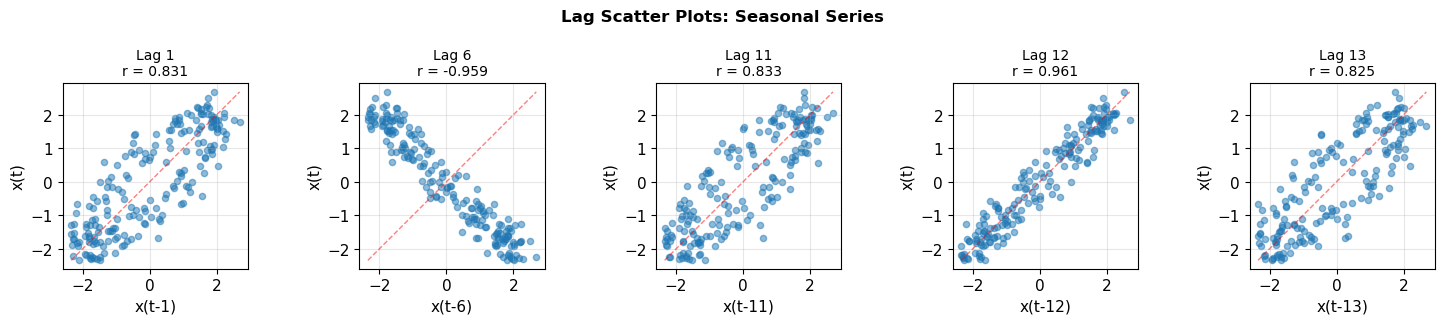

In [27]:
def plot_lag_scatter(data, series_name, lags_to_show=[1, 2, 3, 6, 12]):
    """
    Create scatter plots of x_t vs x_{t-k} for specified lags.
    """
    n_lags = len(lags_to_show)
    fig, axes = plt.subplots(1, n_lags, figsize=(3 * n_lags, 3))
    
    if n_lags == 1:
        axes = [axes]
    
    for ax, k in zip(axes, lags_to_show):
        x_lag = data[:-k]
        x_current = data[k:]
        
        ax.scatter(x_lag, x_current, alpha=0.5, s=20, color='tab:blue')
        
        # Compute correlation for this lag
        corr = np.corrcoef(x_lag, x_current)[0, 1]
        
        # Add diagonal reference line
        lims = [min(x_lag.min(), x_current.min()), max(x_lag.max(), x_current.max())]
        ax.plot(lims, lims, 'r--', alpha=0.5, linewidth=1)
        
        ax.set_title(f"Lag {k}\nr = {corr:.3f}", fontsize=10)
        ax.set_xlabel(f"x(t-{k})")
        ax.set_ylabel("x(t)")
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')
    
    plt.suptitle(f"Lag Scatter Plots: {series_name}", fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Show lag scatter for AR(1) - should show strong correlation at lag 1
plot_lag_scatter(ar1, "AR(1) Process", lags_to_show=[1, 2, 3, 5, 10])

# Show lag scatter for seasonal - should show correlation at lag 12
plot_lag_scatter(seasonal, "Seasonal Series", lags_to_show=[1, 6, 11, 12, 13])


## 9. ACF Heatmap Across Multiple Series

A heatmap view can help compare autocorrelation structures across different series at a glance.


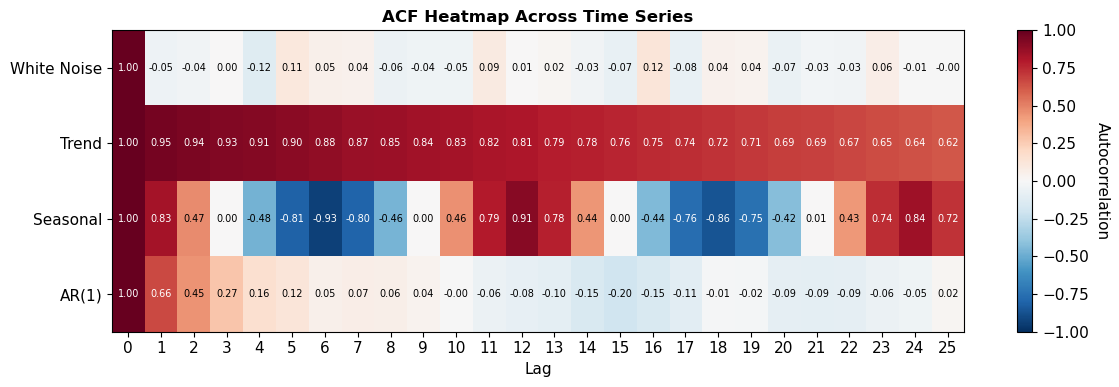

In [28]:
max_lags = 25
lag_labels = [f"Lag {k}" for k in range(max_lags + 1)]
series_names = ["White Noise", "Trend", "Seasonal", "AR(1)"]

# Build matrix: rows = series, cols = lags
acf_matrix = np.zeros((len(series_names), max_lags + 1))
data_list = [white_noise, trend, seasonal, ar1]

for i, data in enumerate(data_list):
    acf_matrix[i, :] = manual_autocorrelation(data, max_lags)

fig, ax = plt.subplots(figsize=(12, 4))

# Use imshow for heatmap
im = ax.imshow(acf_matrix, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)

# Set ticks
ax.set_xticks(np.arange(max_lags + 1))
ax.set_xticklabels([str(k) for k in range(max_lags + 1)])
ax.set_yticks(np.arange(len(series_names)))
ax.set_yticklabels(series_names)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Autocorrelation", rotation=270, labelpad=15)

# Add text annotations
for i in range(len(series_names)):
    for j in range(max_lags + 1):
        val = acf_matrix[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=7)

ax.set_xlabel("Lag")
ax.set_title("ACF Heatmap Across Time Series", fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, max_lags + 0.5)
plt.tight_layout()
plt.show()


## 10. Practical Application: Detecting Stationarity

A key use of ACF is assessing **stationarity**:

| Property | Non-Stationary (Trend) | Stationary |
|----------|----------------------|------------|
| ACF | Decays very slowly | Drops quickly to zero |
| Mean | Changes over time | Constant |
| Variance | May change | Constant |

Let's compare ACF decay rates.


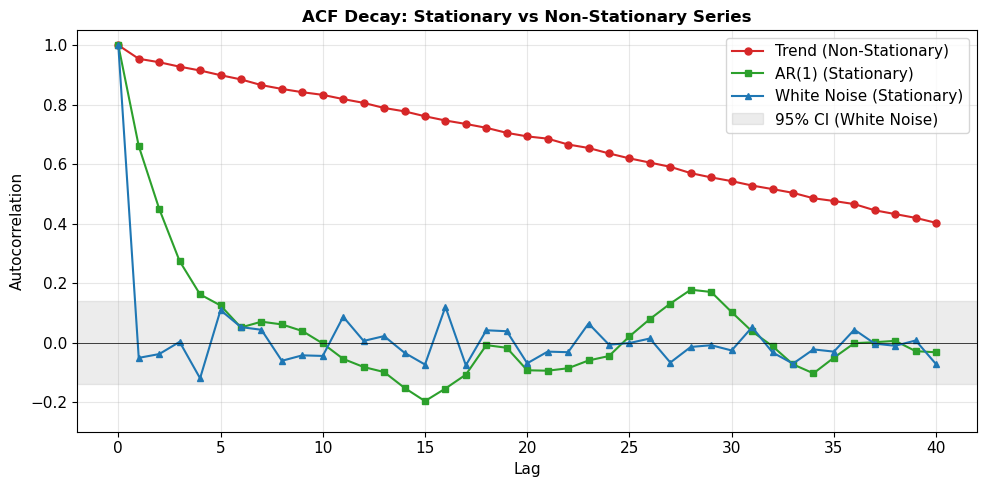

ACF at Lag 10:
  Trend:    0.833  (slow decay -> non-stationary)
  AR(1):    -0.003  (exponential decay -> stationary)
  White Noise: -0.045  (near zero -> stationary)


In [29]:
# Compare ACF decay rates
fig, ax = plt.subplots(figsize=(10, 5))

lags_arr = np.arange(41)

acf_trend = manual_autocorrelation(trend, 40)
acf_ar1 = manual_autocorrelation(ar1, 40)
acf_wn = manual_autocorrelation(white_noise, 40)

ax.plot(lags_arr, acf_trend, 'o-', label='Trend (Non-Stationary)', color='tab:red', markersize=5)
ax.plot(lags_arr, acf_ar1, 's-', label='AR(1) (Stationary)', color='tab:green', markersize=5)
ax.plot(lags_arr, acf_wn, '^-', label='White Noise (Stationary)', color='tab:blue', markersize=5)

ax.axhline(y=0, color='black', linewidth=0.5)
ax.axhspan(-conf_bound, conf_bound, color='gray', alpha=0.15, label='95% CI (White Noise)')

ax.set_xlabel("Lag", fontsize=11)
ax.set_ylabel("Autocorrelation", fontsize=11)
ax.set_title("ACF Decay: Stationary vs Non-Stationary Series", fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.3, 1.05)

plt.tight_layout()
plt.show()

# Print decay metrics
print("ACF at Lag 10:")
print(f"  Trend:    {acf_trend[10]:.3f}  (slow decay -> non-stationary)")
print(f"  AR(1):    {acf_ar1[10]:.3f}  (exponential decay -> stationary)")
print(f"  White Noise: {acf_wn[10]:.3f}  (near zero -> stationary)")


## 11. Summary

| Concept | Formula | Key Insight |
|---------|---------|-------------|
| **Autocovariance** $\gamma(k)$ | $\frac{1}{N}\sum (x_t - \bar{x})(x_{t-k} - \bar{x})$ | Scale-dependent measure of linear dependence |
| **Autocorrelation** $\rho(k)$ | $\gamma(k) / \gamma(0)$ | Scale-free, bounded in $[-1, 1]$ |
| **PACF** | Correlation at lag $k$ controlling for lags $1...k-1$ | Helps identify AR model order |

### Key Takeaways:
1. **ACF** is useful for detecting trends, seasonality, and MA model order.
2. **PACF** is useful for identifying AR model order.
3. Slow ACF decay suggests **non-stationarity** (may need differencing).
4. Always compare ACF values against confidence bounds before concluding significance.
5. 

In [30]:
# Final verification: ensure all functions work correctly
print("=" * 50)
print("VERIFICATION SUMMARY")
print("=" * 50)

for name, data in series_items:
    manual = manual_autocorrelation(data, 10)
    sm = acf(data, nlags=10, fft=True)
    max_diff = np.max(np.abs(manual - sm))
    status = "PASS" if max_diff < 1e-10 else "CHECK"
    print(f"{name:12s}: max diff = {max_diff:.2e}  [{status}]")

print("=" * 50)
print("All cells ready for your Jupyter notebook!")
print("=" * 50)


VERIFICATION SUMMARY
White Noise : max diff = 4.16e-17  [PASS]
Trend       : max diff = 2.22e-16  [PASS]
Seasonal    : max diff = 1.67e-16  [PASS]
AR(1)       : max diff = 1.11e-16  [PASS]
All cells ready for your Jupyter notebook!
